# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [14]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'C:\Users\mazur\data_analysis\data\House_Rent_Dataset.csv')

print(df.shape)

df.head()


(4746, 12)


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [ ]:
# Аналіз пропущених значень

missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

print(missing_percent)

if missing_data.sum() == 0:
    print('Пропущених значень немає')
else :
    print('Є пропущені значення, кількість = ', missing_data)
    

Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64
Пропущених значень немає


In [5]:
# Базова статистика

stats = df.describe()
stats.round()

,BHK,Rent,Size,Bathroom
count,4746.0,4746.0,4746.0,4746.0
mean,2.0,34993.0,967.0,2.0
std,1.0,78106.0,634.0,1.0
min,1.0,1200.0,10.0,1.0
25%,2.0,10000.0,550.0,1.0
50%,2.0,16000.0,850.0,2.0
75%,3.0,33000.0,1200.0,2.0
max,6.0,3500000.0,8000.0,10.0


In [6]:
#Аналіз цільової змінної.

fig_hist_rent = px.histogram(
    df,
    x='Rent',
    nbins=100,
    title='Розподіл цільової змінної (Rent)',
     labels={
        'Rent': 'Орендна плата',
        'count': 'Кількість'
    }
)

fig_hist_rent.update_layout(
    yaxis_title='Кількість'
)

fig_hist_rent.show()

In [8]:
# Знаходимо викиди
# Interquartile range (IQR) = Q3−Q1  ---the distance between the upper and lower quartiles
# Викиди:
# нижня межа = Q1 − 1.5 * IQR
# верхня межа = Q3 + 1.5 * IQR

Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Q1 = ', Q1)
print('Q3 = ', Q3)
print('IQR = ', IQR)
print('lower_bound = ', lower_bound)
print('upper_bound = ', upper_bound)

outliers = df[(df['Rent'] < lower_bound) | (df['Rent'] > upper_bound)]

print("Кількість викидів:", len(outliers))

Q1 =  10000.0
Q3 =  33000.0
IQR =  23000.0
lower_bound =  -24500.0
upper_bound =  67500.0
Кількість викидів: 520


In [9]:
# Видаляємо викиди
df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)]

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4226 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4226 non-null   object
 1   BHK                4226 non-null   int64 
 2   Rent               4226 non-null   int64 
 3   Size               4226 non-null   int64 
 4   Floor              4226 non-null   object
 5   Area Type          4226 non-null   object
 6   Area Locality      4226 non-null   object
 7   City               4226 non-null   object
 8   Furnishing Status  4226 non-null   object
 9   Tenant Preferred   4226 non-null   object
 10  Bathroom           4226 non-null   int64 
 11  Point of Contact   4226 non-null   object
dtypes: int64(4), object(8)
memory usage: 429.2+ KB


In [10]:
# Гістограма Rent без викідів

fig_hist_rent_no_outliers = px.histogram(
    df_clean,
    x='Rent',
    nbins=50,
    title='Розподіл цільової змінної (Rent)',
     labels={
        'Rent': 'Орендна плата',
        'count': 'Кількість'
    }
)

fig_hist_rent_no_outliers.update_layout(
    yaxis_title='Кількість'
)

fig_hist_rent_no_outliers.show()

In [11]:
# Кількість унікальних значень для кожної з категоріальних колонок

df.nunique()

Posted On              81
BHK                     6
Rent                  243
Size                  615
Floor                 480
Area Type               3
Area Locality        2235
City                    6
Furnishing Status       3
Tenant Preferred        3
Bathroom                8
Point of Contact        3
dtype: int64


## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [16]:
# Створюємо датафрейм тільки з числовими метриками
metrics_df = df_clean[['BHK', 'Size', 'Bathroom']].dropna()

# Матриця кореляцій
correlation_matrix = metrics_df.corr()

print(correlation_matrix)
fig.show()

               BHK      Size  Bathroom
BHK       1.000000  0.698453  0.747918
Size      0.698453  1.000000  0.680607
Bathroom  0.747918  0.680607  1.000000


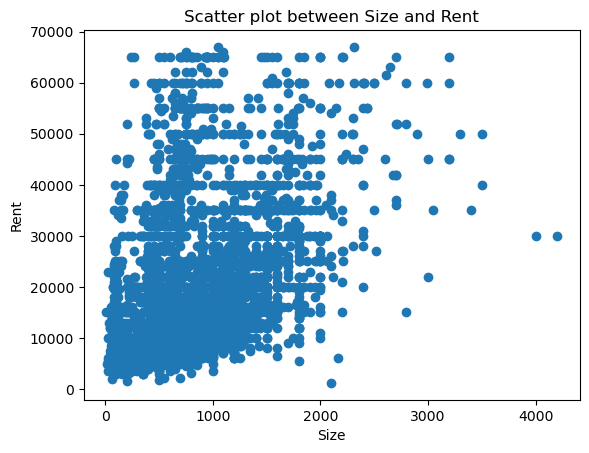

In [15]:
# Побудуйте scatter plot між Size та Rent
plt.figure()
plt.scatter(df_clean["Size"], df_clean["Rent"])
plt.xlabel("Size")
plt.ylabel("Rent")
plt.title("Scatter plot between Size and Rent")
plt.show()

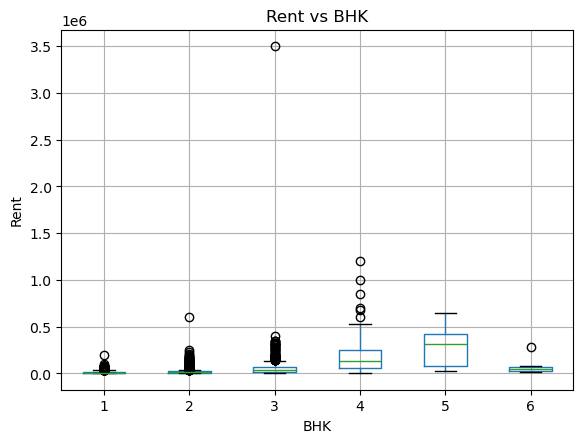

In [ ]:
# Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)
df.boxplot(column='Rent', by='BHK')

plt.title("Rent vs BHK")
plt.suptitle("") 
plt.xlabel("BHK")
plt.ylabel("Rent")

plt.show()

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [20]:
# Копіюю дані щоб не втратити початкові
df_model = df_clean.copy()

In [ ]:
# One-Hot Encoding для платформи
df_model = pd.get_dummies(df_model, columns=[
    "Area Type",
    "City",
    "Furnishing Status",
    "Tenant Preferred",
    "Point of Contact"
])


<bound method DataFrame.info of        Posted On  BHK   Rent  Size            Floor             Area Locality  \
0     2022-05-18    2  10000  1100  Ground out of 2                    Bandel   
1     2022-05-13    2  20000   800       1 out of 3  Phool Bagan, Kankurgachi   
2     2022-05-16    2  17000  1000       1 out of 3   Salt Lake City Sector 2   
3     2022-07-04    2  10000   800       1 out of 2               Dumdum Park   
4     2022-05-09    2   7500   850       1 out of 2             South Dum Dum   
...          ...  ...    ...   ...              ...                       ...   
4741  2022-05-18    2  15000  1000       3 out of 5              Bandam Kommu   
4742  2022-05-15    3  29000  2000       1 out of 4      Manikonda, Hyderabad   
4743  2022-07-10    3  35000  1750       3 out of 5      Himayath Nagar, NH 7   
4744  2022-07-06    3  45000  1500     23 out of 34                Gachibowli   
4745  2022-05-04    2  15000  1000       4 out of 5           Suchitra Circle

In [23]:
print(df_model.shape)        # скільки рядків і колонок
print(df_model.dtypes)       # побачиш що числові залишились int/float

(4226, 25)
Posted On                            object
BHK                                   int64
Rent                                  int64
Size                                  int64
Floor                                object
Area Locality                        object
Bathroom                              int64
Area Type_Built Area                   bool
Area Type_Carpet Area                  bool
Area Type_Super Area                   bool
City_Bangalore                         bool
City_Chennai                           bool
City_Delhi                             bool
City_Hyderabad                         bool
City_Kolkata                           bool
City_Mumbai                            bool
Furnishing Status_Furnished            bool
Furnishing Status_Semi-Furnished       bool
Furnishing Status_Unfurnished          bool
Tenant Preferred_Bachelors             bool
Tenant Preferred_Bachelors/Family      bool
Tenant Preferred_Family                bool
Point of Contact_Cont

In [26]:
# Додаємо нову ознаку: середня вартості житла в місті 

df_model["City_avg_rent"] = df_clean.groupby("City")["Rent"].transform("mean").round(2)

# Додаємо нову ознаку: вартість м2
df_model["Price_per_sqft"] = (df_model["Rent"] / df_model["Size"]).round(2)

In [27]:
print(df_model[["Rent", "Size", "City_avg_rent", "Price_per_sqft"]].head())

    Rent  Size  City_avg_rent  Price_per_sqft
0  10000  1100       11323.27            9.09
1  20000   800       11323.27           25.00
2  17000  1000       11323.27           17.00
3  10000   800       11323.27           12.50
4   7500   850       11323.27            8.82


In [29]:
# Визначаємо X (ознаки) та y (ціль)
X = df_model.drop(columns=["Rent"])  # Ознаки
y = df_model["Rent"] # Цільова змінна

In [32]:
df_model.columns[df_model.columns.duplicated()]

Index([], dtype='object')

In [33]:
print(f"Кількість ознак: {X.shape[1]}")
print(f"Розмір вибірки: {X.shape[0]}")

Кількість ознак: 26
Розмір вибірки: 4226


In [43]:
# Видаляю колонки
print(X.dtypes[X.dtypes == "object"])
X = X.drop(columns=["Posted On", "Floor", "Area Locality"])

Posted On        object
Floor            object
Area Locality    object
dtype: object


In [44]:
# Застосуйте стандартизацію до числових ознак
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ["BHK", "Size", "Bathroom", "City_avg_rent", "Price_per_sqft"]

X[num_cols] = scaler.fit_transform(X[num_cols])

In [45]:
X

,BHK,Size,Bathroom,Area Type_Built Area,Area Type_Carpet Area,Area Type_Super Area,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,...,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Agent,Point of Contact_Contact Builder,Point of Contact_Contact Owner,City_avg_rent,Price_per_sqft
0,0.052966,0.469859,0.272578,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,True,-1.071450,-0.469656
1,0.052966,-0.147778,-1.133910,False,False,True,False,False,False,False,...,True,False,False,True,False,False,False,True,-1.071450,-0.126158
2,0.052966,0.263980,-1.133910,False,False,True,False,False,False,False,...,True,False,False,True,False,False,False,True,-1.071450,-0.298878
3,0.052966,-0.147778,-1.133910,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,True,-1.071450,-0.396033
4,0.052966,-0.044839,-1.133910,False,True,False,False,False,False,False,...,False,True,True,False,False,False,False,True,-1.071450,-0.475485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,0.052966,0.263980,0.272578,False,True,False,False,False,False,True,...,True,False,False,True,False,False,False,True,-0.271503,-0.342058
4742,1.393288,2.322771,1.679065,False,False,True,False,False,False,True,...,True,False,False,True,False,False,False,True,-0.271503,-0.352853
4743,1.393288,1.808073,1.679065,False,True,False,False,False,False,True,...,True,False,False,True,False,True,False,False,-0.271503,-0.234108
4744,1.393288,1.293375,0.272578,False,True,False,False,False,False,True,...,True,False,False,False,True,True,False,False,-0.271503,-0.018208


## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [47]:
# Розділіть дані на навчальну (80%) та тестову (20%) вибірки.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape[0]} рядків")
print(f"Test:  {X_test.shape[0]} рядків")
print(f"Середня оренда в train: {y_train.mean():.0f}")
print(f"Середня оренда в test:  {y_test.mean():.0f}")

Train: 3380 рядків
Test:  846 рядків
Середня оренда в train: 19350
Середня оренда в test:  19033


In [48]:
# Створюємо модель лінійної регресії
from sklearn.linear_model import LinearRegression

# Створюємо модель
model = LinearRegression()

# Навчаємо модель на навчальних даних
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [49]:
# Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
for feature, weight in zip(model.feature_names_in_, model.coef_):
    print(f"{feature}: {weight:.2f}")

print(f"\nЗміщення (intercept): {model.intercept_:.2f}")

BHK: 1642.61
Size: 6418.47
Bathroom: 950.87
Area Type_Built Area: 2207.43
Area Type_Carpet Area: -893.18
Area Type_Super Area: -1314.25
City_Bangalore: 540.69
City_Chennai: -117.82
City_Delhi: -1965.58
City_Hyderabad: -2753.39
City_Kolkata: 1619.12
City_Mumbai: 2676.98
Furnishing Status_Furnished: 2248.50
Furnishing Status_Semi-Furnished: -773.41
Furnishing Status_Unfurnished: -1475.09
Tenant Preferred_Bachelors: 758.48
Tenant Preferred_Bachelors/Family: 288.13
Tenant Preferred_Family: -1046.61
Point of Contact_Contact Agent: 3852.23
Point of Contact_Contact Builder: 160.05
Point of Contact_Contact Owner: -4012.28
City_avg_rent: 5161.47
Price_per_sqft: 4520.35

Зміщення (intercept): 23091.19


In [ ]:
# Висока вартість оренди в мість загалом, розмір квартири, ціна за м2 і оренда через агенцію впливає найбільше на підвищення ціни оренди,
# а оренда через власника, # Type_Super Area, неомебльованість квартири впливає на зменшення ціни

In [52]:
# Зробіть прогнози на тренувальній та тестовій вибірках.
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

comparison = pd.DataFrame({
    "Реальна оренда":    y_test.values[:10],
    "Прогноз моделі":   y_pred_test[:10].round(0),
    'Помилка': (y_test.values[:10] - y_pred_test[:10]).round(0)
})
print(comparison)

   Реальна оренда  Прогноз моделі  Помилка
0           22000         28762.0  -6762.0
1            5000          2719.0   2281.0
2           37000         38729.0  -1729.0
3            8000          2382.0   5618.0
4           15000         14808.0    192.0
5           20000         20797.0   -797.0
6            8500         14403.0  -5903.0
7            7000          4156.0   2844.0
8            3000          -950.0   3950.0
9            8000          4988.0   3012.0


In [53]:
# Виглядає що модель не дуже точна

## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [57]:
# Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):")
print("="*50)
print(f"\nMAE: {mae:.2f} вартість оренди")
print(f"RMSE: {rmse:.2f} вартість оренди")
print(f"R²: {r2:.3f}")

# Порівняння з навчальною вибіркою
mae = mean_absolute_error(y_train, y_pred_train)
mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_pred_train)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:")
print("="*50)
print(f"\nMAE: {mae:.2f} вартість оренди")
print(f"RMSE: {rmse:.2f} вартість оренди")
print(f"R²: {r2_train:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):

MAE: 5124.86 вартість оренди
RMSE: 8451.15 вартість оренди
R²: 0.628
МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:

MAE: 5065.05 вартість оренди
RMSE: 7055.23 вартість оренди
R²: 0.739


In [59]:
# Порівняйте метрики та зробіть висновок про якість моделі
# МАЕ тестове каже про те що модель може помилятися на 5124.86 
# RMSE тестове > МАЕ вказує на те що є випадки де модель помилилася дуже сильно
# R² тестове і тренувальне відрізняються не суттєво, тобто модель не перевчилася
# R² = 0.628, це далеко від 1, але все ще нормальний результат.
# Висновок: модель не найкраща, але допустима

In [60]:
# Візуалізація
# Візуалізація: реальні vs прогнозовані значення
fig = px.scatter(
    x=y_test,
    y=y_pred_test,
    title='Реальні vs Прогнозовані лайки (тестова вибірка)',
    labels={'x': 'Реальні лайки', 'y': 'Прогнозовані лайки'},
    opacity=0.6
)

# Додаємо ідеальну лінію (де прогноз = реальність)
max_val = max(y_test.max(), y_pred_test.max())
fig.add_trace(
    go.Scatter(
        x=[0, max_val],
        y=[0, max_val],
        mode='lines',
        name='Ідеальний прогноз',
        line=dict(color='red', dash='dash')
    )
)

fig.update_layout(height=500)
fig.show()

In [ ]:
# Загалом модель досить точна, точки зосереджені вздовж лінії можелі
# Добре прогнозує коли вартість квартир до 20к
# Від 20к відстань від прогнозованої лінії збільшується, точки стають більш розкиданими


## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)